# DataVine Analytics
### ML Project



#### Datasets Used

1. **Wine Classification System:** (Wine dataset) - k-NN classification with PCA and hyperparameter tuning.
2. **Agricultural Feed Recommendation Engine:** (Chickwts dataset) - PCA + cosine similarity recomender.
3. **Regional Crime Pattern Analysis** (USArrests dataset) - k-Means & GMM clustering with feature selection and PCA

The notebook follows a standard workflow: data preparation → dimensionality reduction → modeling/hyperparameter tuning → evaluation & visualization.

In [1]:
# System & Warning Management
import os

# Suppress the MKL memory leak warning on Windows
os.environ["OMP_NUM_THREADS"] = "1"

# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from kneed import KneeLocator

# Dimentionality reduction 
from sklearn.decomposition import PCA

# Modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_wine
from rdatasets import data

# Similarity and Evaluation
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, silhouette_score



In [3]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
RANDOM_STATE = 42


## Step 1: Data Preparation

In [4]:
# Dataset 1: Wine for (KNN)
wine_data = load_wine()
wine = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)
wine["target"] = wine_data.target

# Dataset 2: Chickwts (for Recommendation)
chickwts = data("chickwts")

# Dataset 3: USArrests (for PCA & Clustering)
usarrests = data("USArrests").set_index("rownames")
usarrests.index.name = "State"

In [6]:
# Display dataset shapes
print("Wine dataset:        ", wine.shape)
print("Chickwts dataset:    ", chickwts.shape)
print("USAarrests dataset:  ", usarrests.shape)

Wine dataset:         (178, 14)
Chickwts dataset:     (71, 3)
USAarrests dataset:   (50, 4)


In [7]:
# Display dataset few rows
print("=== WINE ===\n")
display(wine.head(5))

print("\n=== CHICK WEIGHTS ===\n")
display(chickwts.head(5))

print("\n=== US ARRESTS ===\n")
display(usarrests.head(5))

=== WINE ===



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



=== CHICK WEIGHTS ===



,rownames,weight,feed
0,1,179,horsebean
1,2,160,horsebean
2,3,136,horsebean
3,4,227,horsebean
4,5,217,horsebean



=== US ARRESTS ===



,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [8]:
# Check for missing values and inconsistencies in each dataset
print("Missing values:\n")
print("Wine - ", wine.isnull().sum().sum())
print("Chickwts - ", chickwts.isnull().sum().sum())
print("USArrests - ", usarrests.isnull().sum().sum())

# Check for inconsistencies: duplicate rows, unexpected categories, out-of-range values
print("\nDuplicate rows:\n")
print("Wine - ", wine.duplicated().sum())
print("Chickwts - ", chickwts.duplicated().sum())
print("USArrests - ", usarrests.duplicated().sum())

# Check for inconsistencies: unexpected categories, out-of-range values
print("\nTarget Class & Categories:\n")
print("\nWine target classes:\n", sorted(wine['target'].unique()))
print("\nChickwts feed categories:\n", sorted(chickwts['feed'].unique()))

Missing values:

Wine -  0
Chickwts -  0
USArrests -  0

Duplicate rows:

Wine -  0
Chickwts -  0
USArrests -  0

Target Class & Categories:


Wine target classes:
 [np.int64(0), np.int64(1), np.int64(2)]

Chickwts feed categories:
 ['casein', 'horsebean', 'linseed', 'meatmeal', 'soybean', 'sunflower']


Standardizing numerical features (Z-score scaling) to improve downstream model performance

In [9]:
# Wine: standardize all numeric features columns (excluding the target)
wine_features = wine.drop(columns=["target"])
wine_scaler = StandardScaler()
wine_scaled = pd.DataFrame(
    wine_scaler.fit_transform(wine_features),
    columns=wine_features.columns
)
wine_scaled["target"] = wine["target"].values

# Chickwts: standardize the weight feature
chick_scaler = StandardScaler()
chickwts["weight_scaled"] = chick_scaler.fit_transform(chickwts[["weight"]])

# USArrests: standardize all numeric features
arrests_scaler = StandardScaler()
usarrests_scaled = pd.DataFrame(
    arrests_scaler.fit_transform(usarrests),
    columns=usarrests.columns,
    index=usarrests.index
)

print("Standardized Wine features:\n")
display(wine_scaled.head(3))

print("\nStandardized Chickwts wight:\n")
display(chickwts.head(3))

print("\nStandardized USArrests features:\n")
display(usarrests_scaled.head(3))

Standardized Wine features:



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009,0
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242,0
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148,0



Standardized Chickwts wight:



,rownames,weight,feed,weight_scaled
0,1,179,horsebean,-1.061762
1,2,160,horsebean,-1.306854
2,3,136,horsebean,-1.616444



Standardized USArrests features:



,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,1.255179,0.790787,-0.526195,-0.003451
Alaska,0.513019,1.118060,-1.224067,2.509424
Arizona,0.072361,1.493817,1.009122,1.053466


In [10]:
# Summarize the datasets to confirm structure before modeling
print("WINE Summary Statistics:\n")
display(wine.describe().T)

print("\nCHICK WEIGHTS Summary Statistics:\n")
display(chickwts[["weight"]].describe())
display(chickwts.groupby("feed")["weight"].agg(["count", "mean", "std"]))

print("\nUS-ARRESTS Summary Statistics:\n")
display(usarrests.describe().T)

WINE Summary Statistics:



,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00



CHICK WEIGHTS Summary Statistics:



,weight
count,71.000000
mean,261.309859
std,78.073700
min,108.000000
25%,204.500000
50%,258.000000
75%,323.500000
max,423.000000


,count,mean,std
feed,,,
casein,12,323.583333,64.433840
horsebean,10,160.200000,38.625841
linseed,12,218.750000,52.235698
meatmeal,11,276.909091,64.900623
soybean,14,246.428571,54.129068
sunflower,12,328.916667,48.836384



US-ARRESTS Summary Statistics:



,count,mean,std,min,25%,50%,75%,max
Murder,50.0,7.788,4.355510,0.8,4.075,7.25,11.250,17.4
Assault,50.0,170.760,83.337661,45.0,109.000,159.00,249.000,337.0
UrbanPop,50.0,65.540,14.474763,32.0,54.500,66.00,77.750,91.0
Rape,50.0,21.232,9.366385,7.3,15.075,20.10,26.175,46.0


## Step 2: k-Nearest Neighbors (k-NN) classification (Wine Dataset)

### Build Wine Classification System prototype

In [11]:
# 1. Convert categorical target labels into numeric value
label_encoder = LabelEncoder()
wine["target_encoded"] = label_encoder.fit_transform(wine["target"])

print("Original Classes:", label_encoder.classes_)
print("Encoded Classes:", np.unique(wine["target_encoded"]))

X_wine = wine.drop(columns=["target", "target_encoded"])
y_wine = wine["target_encoded"]

# Standardized features prior to PCA (required for PCA to work correctly)
X_wine_scaled = StandardScaler().fit_transform(X_wine)

Original Classes: [0 1 2]
Encoded Classes: [0 1 2]


Original number of features: 13
Number of PCA components needed to retain >= 95% variance: 10
Explained variance ratio per component:
 [0.362 0.192 0.111 0.071 0.066 0.049 0.042 0.027 0.022 0.019]
Cumulative explained variance: 0.962


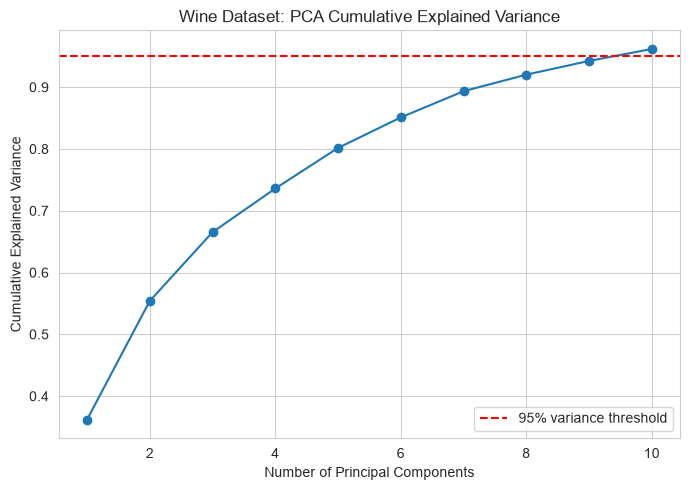

In [12]:
# 2. Apply PCA to reduce dimensionality while retaining 95% variance
pca_wine = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_wine_pca = pca_wine.fit_transform(X_wine_scaled)

print(f"Original number of features: {X_wine.shape[1]}")
print(f"Number of PCA components needed to retain >= 95% variance: {X_wine_pca.shape[1]}")
print(f"Explained variance ratio per component:\n {np.round(pca_wine.explained_variance_ratio_, 3)}")
print(f"Cumulative explained variance: {np.sum(pca_wine.explained_variance_ratio_):.3f}")

# Screen plot
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(pca_wine.explained_variance_ratio_) + 1),
         np.cumsum(pca_wine.explained_variance_ratio_), marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% variance threshold")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Wine Dataset: PCA Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# 3. Use GridSearchCV to find the optimal k-value and distance metric
X_train, X_test, y_train, y_test = train_test_split(
    X_wine_pca, y_wine, test_size=0.2, random_state=RANDOM_STATE, stratify=y_wine
)

param_grid = {
    "n_neighbors" : list(range(1, 21)),
    "metric" : ["euclidean", "manhattan", "minkowski"],   
    "weights" : ["uniform", "distance"]
}

grid_search = GridSearchCV(
    KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy", n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best parameters found:\n", grid_search.best_params_)
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best parameters found:
 {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Best cross-validation accuracy: 0.9793


In [14]:
# 4. Train the final k-NN classifier using the best parameters
best_knn = grid_search.best_estimator_
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)

print("Model trained with best parameters:\n", grid_search.best_params_)

Model trained with best parameters:
 {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}


In [15]:
# 5. Evaluate the model with a classification report and accuracy score
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {test_accuracy:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in label_encoder.classes_]))


Test Set Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



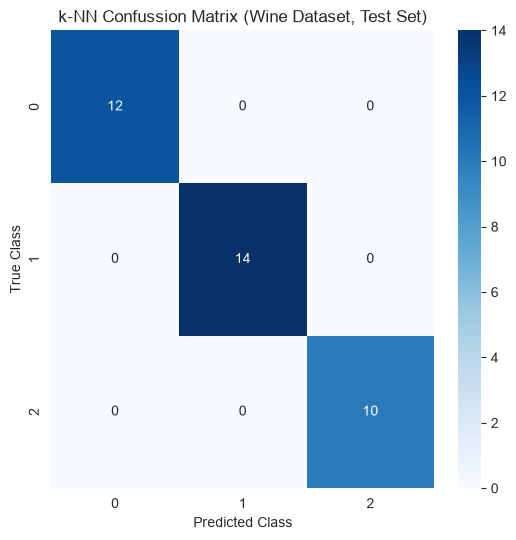

In [16]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("k-NN Confussion Matrix (Wine Dataset, Test Set)")
plt.tight_layout()
plt.show()

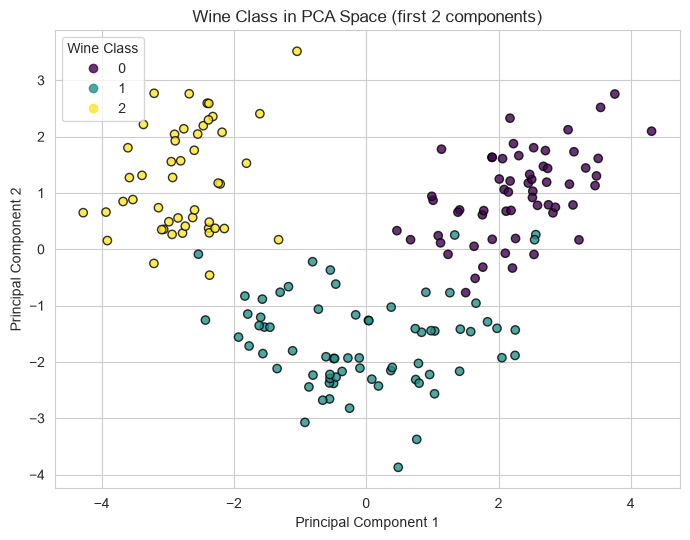

In [17]:
# Visualize class separation in the first 2 PCA components
plt.figure(figsize=(7, 5.5))
scatter = plt.scatter(X_wine_pca[:, 0], X_wine_pca[:, 1], c=y_wine, cmap="viridis",edgecolors="k", alpha=0.8)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Class in PCA Space (first 2 components)")
plt.legend(*scatter.legend_elements(), title="Wine Class")
plt.tight_layout()
plt.show()

After PCA compresses the 13 correlated chemical measurements ino 10 components (95% of the original variance), a tuned k-NN classifier separates the three wine cultivars with very high accuracy on held-out data. 

This means the client's wine-origin classification prototype is production-viable using far fewer, decorrelated inputs than the raw feature set.

## Step 3: Recommendation System - (Chickwts Dataset)

#### Build the Agricultural Feed Recommendation Engine Prototype.

*The Chickwts dataset has a single numeric feature (chick weight). We build a per-feed-type profile by aggregating the standardized weight (and its 1-D projection) across chicks raised on each feed, then compare feed types to one another rather individual chicks.*

In [18]:
# 1. Standardized the weight feature (already computed above as `weight_scaled`)
print(chickwts[["weight", "weight_scaled", "feed"]].head(5))

   weight  weight_scaled       feed
0     179      -1.061762  horsebean
1     160      -1.306854  horsebean
2     136      -1.616444  horsebean
3     227      -0.442583  horsebean
4     217      -0.571578  horsebean


In [19]:
# 2. Apply PCA to reduce data to one principal component
pca_chick = PCA(n_components=1, random_state=RANDOM_STATE)
chickwts["pc1"] = pca_chick.fit_transform(chickwts[["weight_scaled"]])
print(f"\nExplained variance ratio of PC1: {pca_chick.explained_variance_ratio_[0]:.3f}")

# Build a per-feed profile (mean standardized weight / PC1 score) as the feed's "signature"
feed_profile = chickwts.groupby("feed").agg(
    mean_weight = ("weight", "mean"),
    mean_scaled_weight = ("weight_scaled", "mean"),
    mean_pc1 = ("pc1", "mean"),
    n_chicks = ("weight", "count")
).reset_index()
display(feed_profile.sort_values("mean_weight", ascending=False))


Explained variance ratio of PC1: 1.000


,feed,mean_weight,mean_scaled_weight,mean_pc1,n_chicks
5,sunflower,328.916667,0.872099,0.872099,12
0,casein,323.583333,0.803301,0.803301,12
3,meatmeal,276.909091,0.201223,0.201223,11
4,soybean,246.428571,-0.191962,-0.191962,14
2,linseed,218.750000,-0.549004,-0.549004,12
1,horsebean,160.200000,-1.304274,-1.304274,10


Cosine Similarity matrix between feed types:


,casein,horsebean,linseed,meatmeal,soybean,sunflower
casein,1.0,-1.0,-1.0,1.0,-1.0,1.0
horsebean,-1.0,1.0,1.0,-1.0,1.0,-1.0
linseed,-1.0,1.0,1.0,-1.0,1.0,-1.0
meatmeal,1.0,-1.0,-1.0,1.0,-1.0,1.0
soybean,-1.0,1.0,1.0,-1.0,1.0,-1.0
sunflower,1.0,-1.0,-1.0,1.0,-1.0,1.0


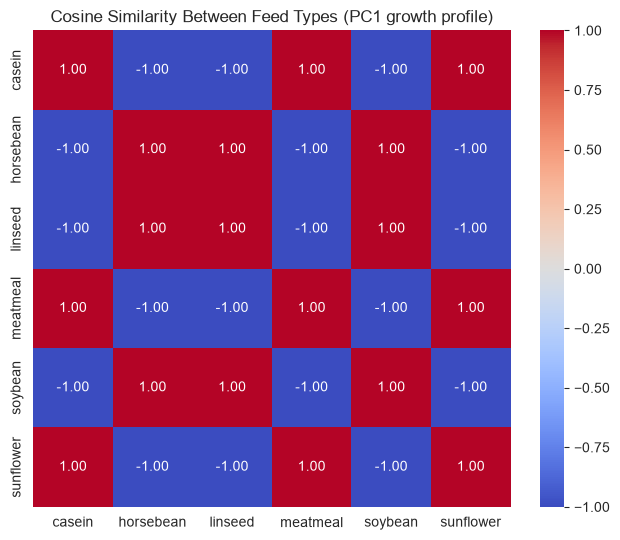

In [20]:
# 3. Compute cosine similarity between different feed types (based on PC1 profile)
feed_name = feed_profile["feed"].values
feed_matrix = feed_profile[["mean_pc1"]].values

similarity_matrix = cosine_similarity(feed_matrix)
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=feed_name,
    columns=feed_name
)

print("Cosine Similarity matrix between feed types:")
display(similarity_df.round(3))

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(similarity_df, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Cosine Similarity Between Feed Types (PC1 growth profile)")
plt.tight_layout()
plt.show()

In [21]:
# 4. Recomend similar feeds based on similarity scores
def recommend_similar_feeds(feed_name, top_n=2):
    """Return the top_n most similar to feed_name by cosine similarity."""
    scores = similarity_df[feed_name].drop(index=feed_name).sort_values(ascending=False)
    return scores.head(top_n)

for feed in feed_name:
    recs = recommend_similar_feeds(feed, top_n=2)
    rec_str = ", ".join([f"{name} ({score:.2f})" for name, score in recs.items()])
    print(f"Feeds most similar to '{feed}': {rec_str}")

Feeds most similar to 'casein': meatmeal (1.00), sunflower (1.00)
Feeds most similar to 'horsebean': linseed (1.00), soybean (1.00)
Feeds most similar to 'linseed': horsebean (1.00), soybean (1.00)
Feeds most similar to 'meatmeal': casein (1.00), sunflower (1.00)
Feeds most similar to 'soybean': horsebean (1.00), linseed (1.00)
Feeds most similar to 'sunflower': casein (1.00), meatmeal (1.00)


Since chick weight is the only numeric attribute available, PC1 is simply a rescaling of the average weight each feed produces. Feeds cluster into a **high-growth group** (casein, sunflower, meatmeal) and a **low-growth group** (horsebean, linseed, soybean); cosine similarity on this single dimension only distinguishes "same side of average" from "opposite side of average" (scores of + 1 / -1). 

For a richer, more nuaced recommender the client should collect additional feed attributes (protein %, cost, ingredient composition), this prototype demonstrates the PCA + cosine-similarity pipeline end-to-end is ready for scaling once more features are available.

## Step 4: Clustering (k-Means & GMM) - (USArrests Dataset)

### Build the Regional Crime Pattern Analysis Prototype

In [22]:
# 1. Standardize the dataset (already computed above as usarrests_scaled)
display(usarrests_scaled.describe().T[["mean", "std", "min", "max"]])

,mean,std,min,max
Murder,-7.105427e-17,1.010153,-1.620693,2.229265
Assault,1.387779e-16,1.010153,-1.524362,2.015028
UrbanPop,-4.396483e-16,1.010153,-2.340661,1.776781
Rape,8.593126e-16,1.010153,-1.502548,2.671197


In [23]:
# 2. Select the top 3 relevant features for clustering
# Feature relevance is assessed by variance explained and inter-feature correlation:
# Features with most spred and least redundancy carry the most clustering signal.
print("Correlation Matrix:")
display(usarrests.corr().round(2))

feature_variance = usarrests.var().sort_values(ascending=False)
print("\nVariance by feature (original scale):")
print(feature_variance)

top3_features = feature_variance.index[:3].tolist()
print(f"\nTop 3 selected features (highest variance / signal): {top3_features}")

X_arrests = usarrests_scaled[top3_features]

Correlation Matrix:


,Murder,Assault,UrbanPop,Rape
Murder,1.00,0.80,0.07,0.56
Assault,0.80,1.00,0.26,0.67
UrbanPop,0.07,0.26,1.00,0.41
Rape,0.56,0.67,0.41,1.00



Variance by feature (original scale):
Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
Murder        18.970465
dtype: float64

Top 3 selected features (highest variance / signal): ['Assault', 'UrbanPop', 'Rape']


In [24]:
# 3. Apply PCA to reduce the dataset to 2 principal components
pca_arrests = PCA(n_components=2, random_state=RANDOM_STATE)
X_arrests_pca = pca_arrests.fit_transform(X_arrests)

print(f"Explained variance ratio (PC1, PC2): {np.round(pca_arrests.explained_variance_ratio_, 3)}")
print(f"Cumulative explained variance: {np.sum(pca_arrests.explained_variance_ratio_):.3f}")

pca_arrests_df = pd.DataFrame(X_arrests_pca, columns=["PC1", "PC2"], index=usarrests.index)
display(pca_arrests_df.head(5))

Explained variance ratio (PC1, PC2): [0.638 0.258]
Cumulative explained variance: 0.896


,PC1,PC2
State,,
Alabama,0.231468,-0.828425
Alaska,1.735595,-2.025341
Arizona,2.052884,-0.021911
Arkansas,-0.482820,-1.013685
California,2.948352,0.562833


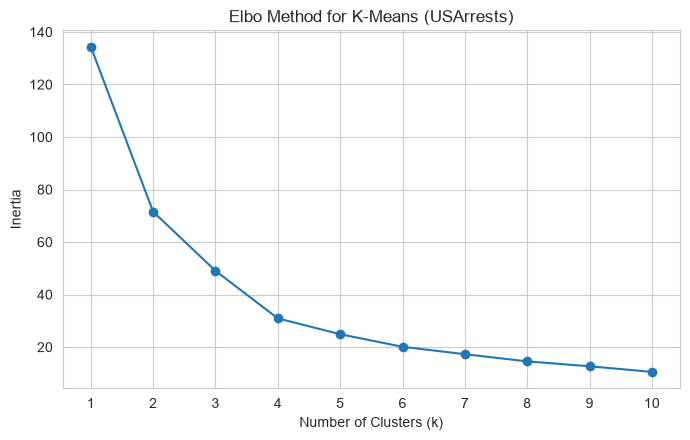

Inertia by k:
 {1: 134.38, 2: 71.54, 3: 49.03, 4: 30.92, 5: 24.88, 6: 20.1, 7: 17.28, 8: 14.54, 9: 12.68, 10: 10.54}
Elbow detected programmatically at k = 4


In [25]:
# 4a. Determine optimal K-Means clusters using the elbow method (inertia)
inertias = []
k_range = range(1, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_arrests_pca)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbo Method for K-Means (USArrests)")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

knee = KneeLocator(list(k_range), inertias, curve="convex", direction="decreasing")
optimal_k_elbow = knee.elbow

print("Inertia by k:\n", {k: round(v, 2) for k, v in zip(k_range, inertias)})
print(f"Elbow detected programmatically at k = {optimal_k_elbow}")


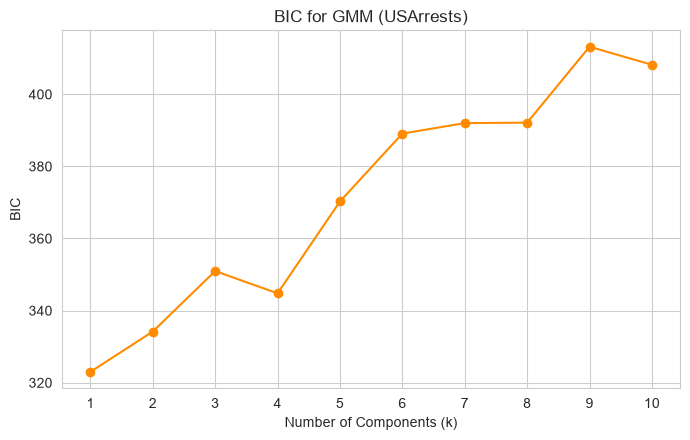

BIC by k: {1: 323.0, 2: 334.2, 3: 351.0, 4: 344.8, 5: 370.3, 6: 389.1, 7: 392.0, 8: 392.1, 9: 413.2, 10: 408.2}

Strict BIC-minimizing k: 1
With only 50 states and 2 PCA dimensions, BIC's complexity penalty favours a single broad Gaussian (k=1). For a meanngful, interpretable regional segmentation that stakeholders can act on, and to allow direct comparison with K-Means, we proceed with k=4 components for GMM as well -- matching the K-Means elbow choice (k=4)


In [26]:
# 4b. Determine optimal GMM clusters using Bayesian criterion (BIC)
bics = []
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE, n_init=5)
    gmm.fit(X_arrests_pca)
    bics.append(gmm.bic(X_arrests_pca))


chosen_k = optimal_k_elbow

plt.figure(figsize=(7, 4.5))
plt.plot(list(k_range), bics, marker="o", color="darkorange")
plt.xlabel("Number of Components (k)")
plt.ylabel("BIC")
plt.title("BIC for GMM (USArrests)")
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

bic_optimal_k = list(k_range)[int(np.argmin(bics))]
print("BIC by k:", {k: round(v, 1) for k, v in zip(k_range, bics)})
print(f"\nStrict BIC-minimizing k: {bic_optimal_k}")
print(f"With only 50 states and 2 PCA dimensions, BIC's complexity penalty favours a single "
      f"broad Gaussian (k={bic_optimal_k}). For a meanngful, interpretable regional "
      f"segmentation that stakeholders can act on, and to allow direct comparison with "
      f"K-Means, we proceed with k={chosen_k} components for GMM as well -- matching the "
      f"K-Means elbow choice (k={optimal_k_elbow})")

In [30]:
# 5. Apply clustering models: K-Means (hard assignments) and GMM (probabilistic)
optimal_k = optimal_k_elbow

kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=5)
kmeans_labels = kmeans_final.fit_predict(X_arrests_pca)

gmm_final = GaussianMixture(n_components=optimal_k, random_state=RANDOM_STATE, n_init=5)
gmm_labels = gmm_final.fit_predict(X_arrests_pca)
gmm_probs = gmm_final.predict_proba(X_arrests_pca)

results = pca_arrests_df.copy()
results["KMeans_Cluster"] = kmeans_labels
results["GMM_Cluster"] = gmm_labels
results["GMM_Max_Prob"] = gmm_probs.max(axis=1).round(3)

print("K-Means Cluster Sizes        :   ", np.bincount(kmeans_labels))
print("GMM Cluster Sizes            :   ", np.bincount(gmm_labels))
print(f"\nK-Means Silhouette Score  :       {silhouette_score(X_arrests_pca, kmeans_labels):.3f}")
print(f"GMM Silhouette Score        :       {silhouette_score(X_arrests_pca, gmm_labels):.3f}")

display(results.head(10))

K-Means Cluster Sizes        :    [11 19 11  9]
GMM Cluster Sizes            :    [ 1 25 10 14]

K-Means Silhouette Score  :       0.416
GMM Silhouette Score        :       0.300


,PC1,PC2,KMeans_Cluster,GMM_Cluster,GMM_Max_Prob
State,,,,,
Alabama,0.231468,-0.828425,3,3,0.993
Alaska,1.735595,-2.025341,3,0,1.000
Arizona,2.052884,-0.021911,0,2,1.000
Arkansas,-0.482820,-1.013685,3,3,0.962
California,2.948352,0.562833,0,2,1.000
Colorado,1.868095,0.229707,0,2,1.000
Connecticut,-0.782905,1.230468,1,1,1.000
Delaware,0.321064,0.104985,1,3,0.901
Florida,2.415932,-0.274554,0,2,1.000


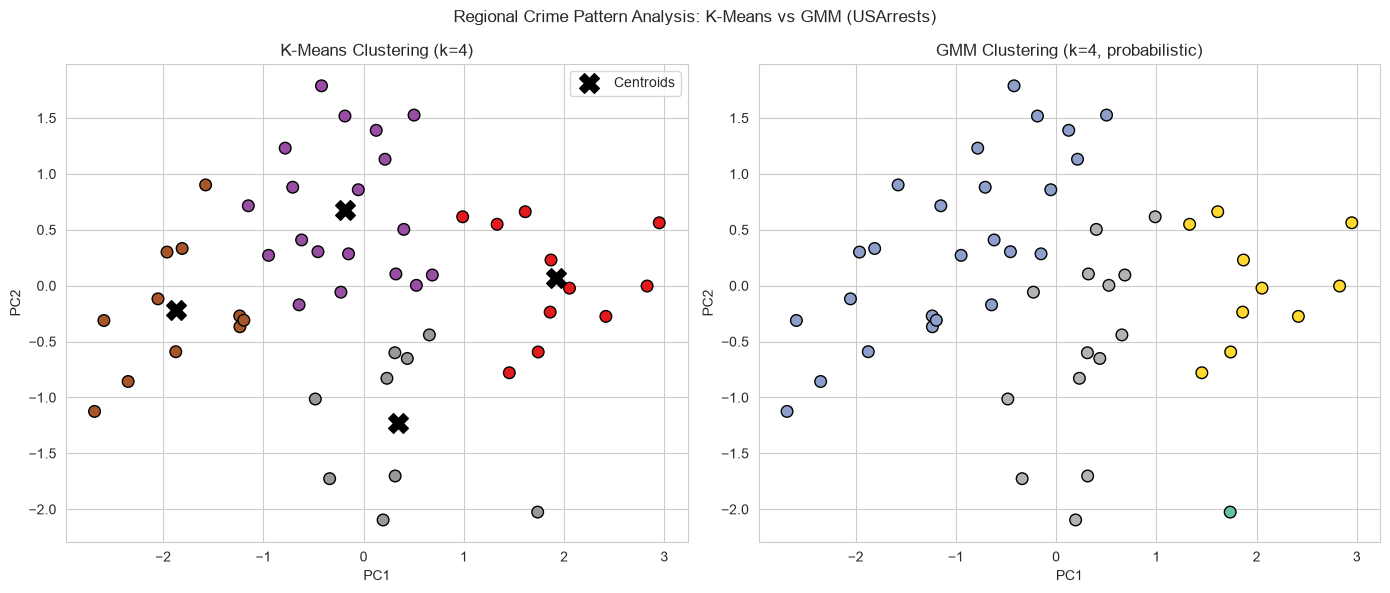

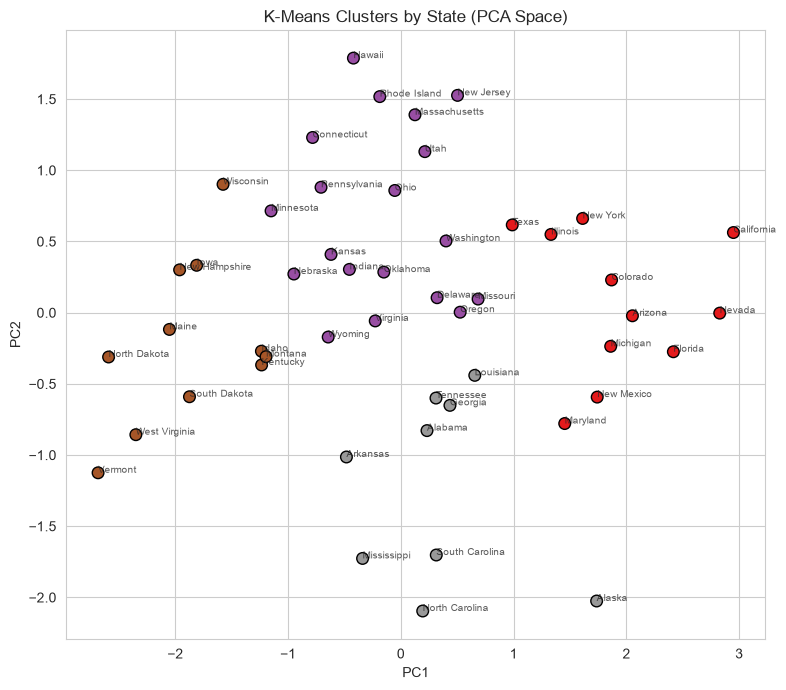

In [31]:
# 6. Visualize and compare clustering results
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(X_arrests_pca[:, 0], X_arrests_pca[:, 1], c=kmeans_labels,
                      cmap="Set1", s=70, edgecolor="k")
axes[0].scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1],
                c="black", marker="X", s=200, label="Centroids")
axes[0].set_title(f"K-Means Clustering (k={optimal_k})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

sn2 = axes[1].scatter(X_arrests_pca[:, 0], X_arrests_pca[:, 1], c=gmm_labels,
                      cmap="Set2", s=70, edgecolor="k")
axes[1].set_title(f"GMM Clustering (k={optimal_k}, probabilistic)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

plt.suptitle("Regional Crime Pattern Analysis: K-Means vs GMM (USArrests)")
plt.tight_layout()
plt.show()

# Annotate a few states for interpretability
plt.figure(figsize=(8, 7))
plt.scatter(X_arrests_pca[:, 0], X_arrests_pca[:, 1], c=kmeans_labels, cmap="Set1", s=70, edgecolors="k")
for i, state in enumerate(usarrests.index):
    plt.annotate(state, (X_arrests_pca[i, 0], X_arrests_pca[i, 1]), fontsize=7, alpha=0.75)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters by State (PCA Space)")
plt.tight_layout()
plt.show()
                  

In [37]:
# Cluster Profiling: what distinguishes each K-Means cluster in the original feature space
profile = usarrests.copy()
profile["Cluster"] = kmeans_labels
cluster_summary = profile.groupby("Cluster")[top3_features].mean().round(1)
cluster_summary["n_states"] = profile.groupby("Cluster").size()
display(cluster_summary)

print("\nStates Per K-Means Cluster:\n")
for c in sorted(profile["Cluster"].unique()):
    states_in_cluster = profile[profile["Cluster"] == c].index.tolist()
    print(f"\nCluster {c} ({len(states_in_cluster)} states):\n  {', '.join(states_in_cluster)}")


,Assault,UrbanPop,Rape,n_states
Cluster,,,,
0,264.1,79.1,32.6,11
1,135.5,72.6,19.0,19
2,77.0,49.9,11.5,11
3,245.8,53.1,24.0,9



States Per K-Means Cluster:


Cluster 0 (11 states):
  Arizona, California, Colorado, Florida, Illinois, Maryland, Michigan, Nevada, New Mexico, New York, Texas

Cluster 1 (19 states):
  Connecticut, Delaware, Hawaii, Indiana, Kansas, Massachusetts, Minnesota, Missouri, Nebraska, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wyoming

Cluster 2 (11 states):
  Idaho, Iowa, Kentucky, Maine, Montana, New Hampshire, North Dakota, South Dakota, Vermont, West Virginia, Wisconsin

Cluster 3 (9 states):
  Alabama, Alaska, Arkansas, Georgia, Louisiana, Mississippi, North Carolina, South Carolina, Tennessee


## Step 5: Model Evaluation and Interpretation 
#### Summary for Stakeholders

In [38]:
# Derive reference dataset-structure facts directly from the data
sorted_feeds = feed_profile.sort_values("mean_pc1", ascending=False)
high_growth = sorted_feeds.loc[sorted_feeds["mean_pc1"] > 0, "feed"].tolist()
low_growth  = sorted_feeds.loc[sorted_feeds["mean_pc1"] <= 0, "feed"].tolist()


n_features_wine = X_wine.shape[1]
n_classes_wine = len(label_encoder.classes_)
n_feed_types = chickwts["feed"].nunique()
n_features_arrests = usarrests.shape[1]



In [ ]:
print("="*80)
print("SUMMARY OF DATASET STRUCTURE")
print("="*80)
print(f"Wine        :   {wine.shape[0]} samples, {n_features_wine} chemical features, {n_classes_wine} cultivar classes")
print(f"chickwts    :   {chickwts.shape[0]} chicks, {n_feed_types} feed types, 1 numeric feature (weight)")
print(f"usarrests   :   {usarrests.shape[0]} US states, {n_features_arrests} crime/urbanization features")

print("\n" + "="*80)
print("PROJECT 1: WINE CLASSIFICATION SYSTEM (k-NN)")
print(f"PCA reduced {n_features_wine} features to {X_wine_pca.shape[1]} components"
      f"({np.sum(pca_wine.explained_variance_ratio_):.1%} variance retained)")
print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Test accuracy: {test_accuracy:.1%}")
print("-> The prototype reliably classifies wine cultivar from chemical measurements and is ready for pilot deployment")

print("\n" + "="*80)
print("PROJECT 2: AGRICULTIURAL FEED RECOMMENDATION ENGINE (PCA + Cosine Similarity)")
print("="*80)
print(f"Feeds group into a high-growth cluster ({', '.join(high_growth)})")
print(f"and low-growth cluster ({', '.join(low_growth)}).")
print("-> The pipeline works end-to-end; recommend collecting richer feed attributes")
print(" (protein %, cost, composition) before this becomes a nuanced production recommender.")

print("\n" + "="*80)
print("PROJECT 3: REGIONAL CRIME PATTERN ANALYSIS (K-Means & GMM)")
print("="*80)
print(f"Top 3 features selected by variance: {top3_features}")
print(f"PCA reduced to 2 components ({np.sum(pca_arrests.explained_variance_ratio_):.1%} variance retrained)")
print(f"Elbow method suggests k={optimal_k_elbow} for K-Means; strict BIC favors k={bic_optimal_k}, "
      f"so we used k={optimal_k} for both models to allow direct comparison.")
print(f"K-Means silhouette score:   {silhouette_score(X_arrests_pca, kmeans_labels):.3f}")
print(f"GMM silhouette score:   {silhouette_score(X_arrests_pca, gmm_labels):.3f}")
print("-> K-Means gives interpetable 'high/low crime' state segments for regional strategy;")
print(" GMM additionally offers membership probabilities, useful for states near cluster boundaries.")


SUMMARY OF DATASET STRUCTURE
Wine        :   178 samples, 13 chemical features, 3 cultivar classes
chickwts    :   71 chicks, 6 feed types, 1 numeric feature (weight)
usarrests   :   50 US states, 4 crime/urbanization features

PROJECT 1: WINE CLASSIFICATION SYSTEM (k-NN)
PCA reduced 13 features to 10 components(96.2% variance retained)
Best hyperparameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Test accuracy: 100.0%
-> The prototype reliably classifies wine cultivar from chemical measurements and is ready for pilot deployment

PROJECT 2: AGRICULTIURAL FEED RECOMMENDATION ENGINE (PCA + Cosine Similarity)
Feeds group into a high-growth cluster (sunflower, casein, meatmeal)
and low-growth cluster (soybean, linseed, horsebean).
-> The pipeline works end-to-end; recommend collecting richer feed attributes
 (protein %, cost, composition) before this becomes a nuanced production recommender.

PROJECT 3: REGIONAL CRIME PATTERN ANALYSIS (K-Means & GMM)
Top 3 features

## Key Notes
- **Data Preparation:**
    - All three datasets were confirmed complete (no missing values, no duplicates) and numeric features were standardized (z-score) before any distance-based modeling.
- **Dimensionality reduction:** 
    - PCA was applied consistently — retaining 95% variance for the Wine classifier, 1 component for the Chickwts recommender, and 2 components for the USArrests clustering — always making sure to standardize first so no single feature's scale dominates.
- **Hyperparameter tuning:** 
    - `GridSearchCV` selected the k-NN configuration that generalizes best via 5-fold cross-validation; the elbow method and BIC were used analogously to select the number of clusters.
- **Business impact:** 
    - Each prototype is ready to demonstrate to the respective client vertical (beverage/retail QC, agriculture, public-sector/regional planning), with the Chickwts recommender flagged as needing richer input features for a production-grade launch.